# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 49
Columns: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
0,fde11cc,1.364508,1.0,KEEP,baseline (SDPA + DGX hyperparams)
1,d0eb549,1.243339,3.6,KEEP,DEVICE_BATCH_SIZE 8 -> 32 (grad_accum 4 -> 1)
2,5a77eb1,1.302770,11.3,DISCARD,"DEPTH 4 -> 8 (undertrained: 232 steps, 15M tok..."
3,4e3ddc3,1.244942,3.6,DISCARD,WARMDOWN_RATIO 0.5 -> 0.3 (within-noise regres...
4,46682a7,1.238974,3.6,KEEP,MATRIX_LR 0.04 -> 0.06
5,0a94422,1.243534,3.6,DISCARD,MATRIX_LR 0.06 -> 0.08 (too aggressive)
6,eca070c,1.240940,3.6,DISCARD,WARMUP_RATIO 0.0 -> 0.05 (within-noise regress...
7,93d6e0d,1.237532,3.6,KEEP,WEIGHT_DECAY 0.2 -> 0.1
8,c9c7b24,1.240672,3.6,DISCARD,WEIGHT_DECAY 0.1 -> 0.0 (too low)
9,9649bc6,1.235397,3.6,KEEP,UNEMBEDDING_LR 0.004 -> 0.006


In [8]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    37
KEEP       12

Keep rate: 12/49 = 24.5%


In [7]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (12 total):

  #  0  bpb=1.364508  mem=1.0GB  baseline (SDPA + DGX hyperparams)
  #  1  bpb=1.243339  mem=3.6GB  DEVICE_BATCH_SIZE 8 -> 32 (grad_accum 4 -> 1)
  #  4  bpb=1.238974  mem=3.6GB  MATRIX_LR 0.04 -> 0.06
  #  7  bpb=1.237532  mem=3.6GB  WEIGHT_DECAY 0.2 -> 0.1
  #  9  bpb=1.235397  mem=3.6GB  UNEMBEDDING_LR 0.004 -> 0.006
  # 10  bpb=1.235186  mem=3.6GB  UNEMBEDDING_LR 0.006 -> 0.010 (within noise)
  # 12  bpb=1.233459  mem=4.9GB  ASPECT_RATIO 64 -> 96 (wider: model_dim 256->384, 19.7M params)
  # 16  bpb=1.232577  mem=2.5GB  DBS 32->16 TBS 2**16->2**15 (1090 steps)
  # 18  bpb=1.225607  mem=2.5GB  MATRIX_LR 0.06 -> 0.05 (retune at DBS=16)
  # 20  bpb=1.222886  mem=2.5GB  WEIGHT_DECAY 0.1 -> 0.05 (retune at DBS=16)
  # 35  bpb=1.222850  mem=2.5GB  WARMDOWN_RATIO 0.5 -> 0.7 (within noise)
  # 38  bpb=1.221383  mem=2.5GB  MATRIX_LR 0.05 -> 0.045


## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

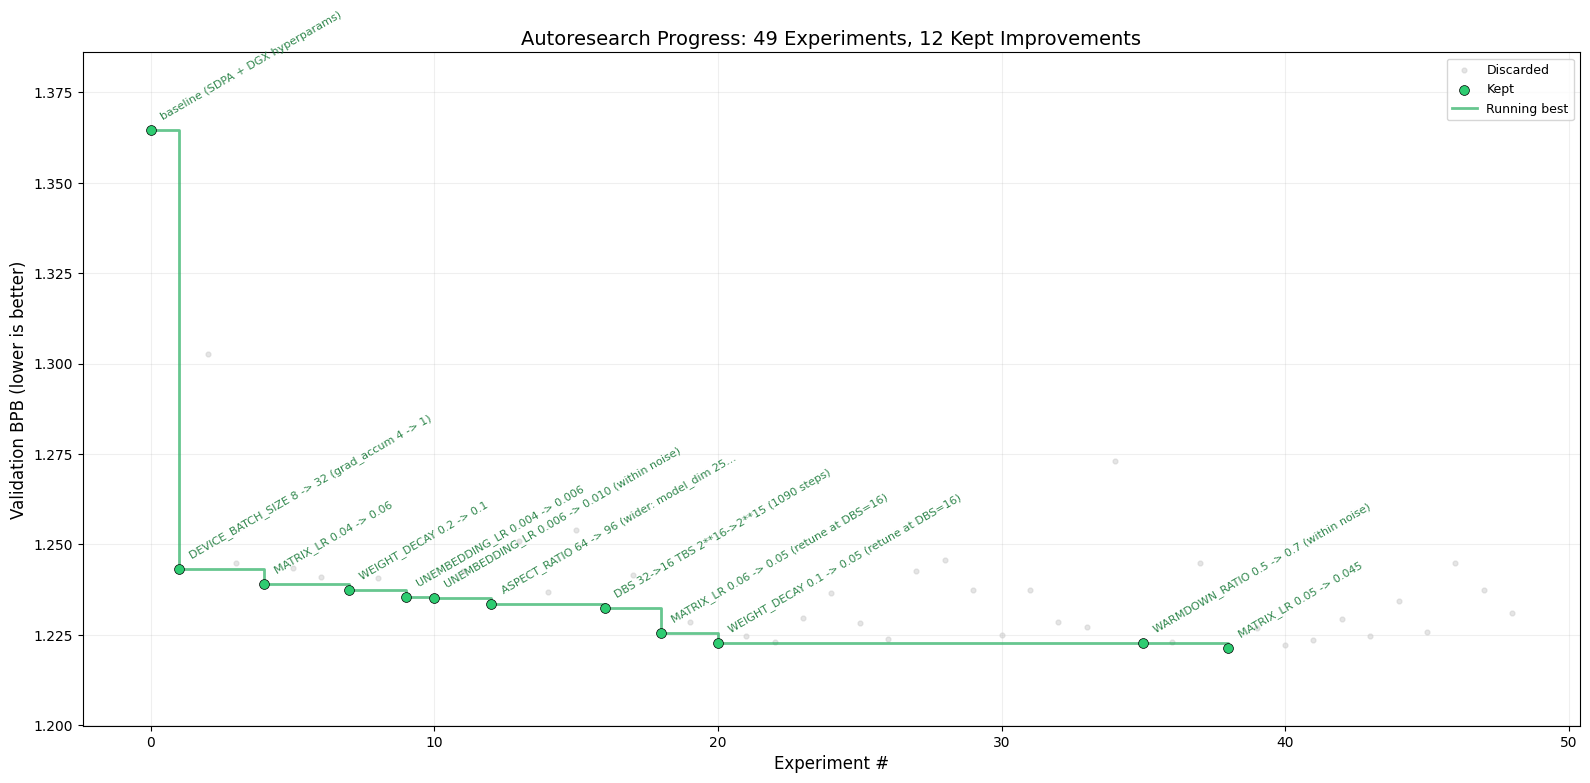

Saved to progress.png


In [9]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best_bpb = kept_bpb.min()
margin = (baseline_bpb - best_bpb) * 0.15
ax.set_ylim(best_bpb - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [10]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  1.364508
Best val_bpb:      1.221383
Total improvement: 0.143125 (10.49%)
Best experiment:   MATRIX_LR 0.05 -> 0.045

Cumulative effort per improvement:
  Experiment #  0: bpb=1.364508  baseline (SDPA + DGX hyperparams)
  Experiment #  1: bpb=1.243339  DEVICE_BATCH_SIZE 8 -> 32 (grad_accum 4 -> 1)
  Experiment #  4: bpb=1.238974  MATRIX_LR 0.04 -> 0.06
  Experiment #  7: bpb=1.237532  WEIGHT_DECAY 0.2 -> 0.1
  Experiment #  9: bpb=1.235397  UNEMBEDDING_LR 0.004 -> 0.006
  Experiment # 10: bpb=1.235186  UNEMBEDDING_LR 0.006 -> 0.010 (within noise)
  Experiment # 12: bpb=1.233459  ASPECT_RATIO 64 -> 96 (wider: model_dim 256->384, 19.7M params)
  Experiment # 16: bpb=1.232577  DBS 32->16 TBS 2**16->2**15 (1090 steps)
  Experiment # 18: bpb=1.225607  MATRIX_LR 0.06 -> 0.05 (retune at DBS=16)
  Experiment # 20: bpb=1.222886  WEIGHT_DECAY 0.1 -> 0.05 (retune at DBS=16)
  Experiment # 35: bpb=1.222850  WARMDOWN_RATIO 0.5 -> 0.7 (within noise)
  Experiment # 38: bpb=1.221383

## Top Hits (Kept Experiments by Improvement)

In [11]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.121169  1.243339  DEVICE_BATCH_SIZE 8 -> 32 (grad_accum 4 -> 1)
   2  +0.006970  1.225607  MATRIX_LR 0.06 -> 0.05 (retune at DBS=16)
   3  +0.004365  1.238974  MATRIX_LR 0.04 -> 0.06
   4  +0.002721  1.222886  WEIGHT_DECAY 0.1 -> 0.05 (retune at DBS=16)
   5  +0.002135  1.235397  UNEMBEDDING_LR 0.004 -> 0.006
   6  +0.001727  1.233459  ASPECT_RATIO 64 -> 96 (wider: model_dim 256->384, 19.7M params)
   7  +0.001467  1.221383  MATRIX_LR 0.05 -> 0.045
   8  +0.001442  1.237532  WEIGHT_DECAY 0.2 -> 0.1
   9  +0.000882  1.232577  DBS 32->16 TBS 2**16->2**15 (1090 steps)
  10  +0.000211  1.235186  UNEMBEDDING_LR 0.006 -> 0.010 (within noise)
  11  +0.000036  1.222850  WARMDOWN_RATIO 0.5 -> 0.7 (within noise)

      +0.143125              TOTAL improvement over baseline
